# FOMC-Blackout — a quantitative teardown 🔬
### Real total-return tape · HAC/Welch inference · calendar placebo · decay split · excess-Sharpe race · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calm_before_the_storm%3F: Busted](https://img.shields.io/badge/Calm_before_the_storm%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the ~10-day pre-meeting FOMC communications blackout carries an excess return (and lower volatility) over the rest of the year, and whether any of it is tradable.

> ⚠️ **Not investment advice.** Real data: SPY daily auto-adjusted (total-return proxy), 1994-2026; as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/, _cache/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_blackout import data, strategy as st

def load_real_safe():
    """Cache-first real tape; None if offline with no cache."""
    try:
        return data.load_real(fetch=False)
    except Exception as e:
        print("no real cache (", type(e).__name__, ") -> using frozen numbers / synthetic tape")
        return None

REAL = load_real_safe()
HAVE_REAL = REAL is not None
print("real SPY total-return cache present:", HAVE_REAL)


real SPY total-return cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | blackout − other = **+0.27 bps/day**, Welch *t* = **+0.08**; placebo flat; pre/post-2011 sign flips (+2.67 → -2.35 bps). |
| **Tradability** | `MIRAGE` | blackout-only book +2.7%/yr vs +12.1%/yr B&H; excess Sharpe 0.30 vs 0.64 — a fraction of beta, before any cost. |
| **Calm before the storm?** | `BUSTED` | window vol ratio **1.03** (higher, not lower). |

> 💡 In plain words: the blackout window earns plain equity drift, is no calmer than any other fortnight, and as a timing rule just throws away ~79% of the year's return.

## 1 · The claim, steelmanned

Let $r_t$ be the daily total return and $B_t\in\{0,1\}$ the pre-meeting blackout flag ($B_t=1$ iff $t$ is within 10 calendar days *before* a scheduled FOMC decision):

- **H₁ (excess drift).** $\mathbb{E}[r_t\mid B_t{=}1] > \mathbb{E}[r_t\mid B_t{=}0]$ — the *difference*, not the level.
- **H₂ (calm).** $\mathrm{Var}[r_t\mid B_t{=}1] < \mathrm{Var}[r_t\mid B_t{=}0]$.
- **H₃ (localised).** The diff peaks at the true window and fades as it slides off the meeting (placebo).
- **H₄ (tradable).** A blackout-only timing book beats buy-and-hold on excess Sharpe.

We find **H₁–H₄ all rejected.** The level of the blackout arm is positive only because it inherits the market's drift (H₀: it's beta).

## 2 · So what? — what rides on each answer

The nearby *real* effect is Lucca & Moench's (2015) **pre-FOMC announcement drift**: a ~49 bps excess in the **24 hours** before scheduled meetings, a meaningful chunk of the equity premium. The folklore quietly upgrades that one-day spark into a ten-day, low-vol, sit-in-it window. If that upgrade held, it would be an unusually clean calendar trade. The content of this study is *precisely where the upgrade fails*: spreading a one-day effect over ten days averages it to noise, and the 'calm' half of the story was never in the data at all.

## 3 · How we'd know — the protocol

- **Flag.** $B_t = 1$ for trading days within 10 calendar days before each scheduled FOMC date (the public schedule — **no execution lag needed**, the label is calendar-known months ahead).
- **Inference.** Per-arm Newey-West HAC *t*; Welch *t* on the blackout-minus-other difference (the decisive test).
- **Localisation.** Calendar-shift placebo: slide the window by ±5/10/20 days and re-measure.
- **Decay.** Pre/post-2011 split (after Lucca-Moench; McLean-Pontiff decay).
- **Calm.** Annualised vol, blackout vs rest.
- **Tradability.** Long-only-in-blackout book, costs one-way × NAV, raced against B&H on **excess-of-cash** Sharpe.
- **Positive control.** Deterministic synthetic tape with a tunable planted excess and vol multiplier.

Tape: SPY daily total return, 1994-2026.

## 4 · The teardown

### 4a · Blackout vs rest — the level is beta, the diff is zero

Per-arm mean and HAC *t*, plus the Welch *t* on the difference.

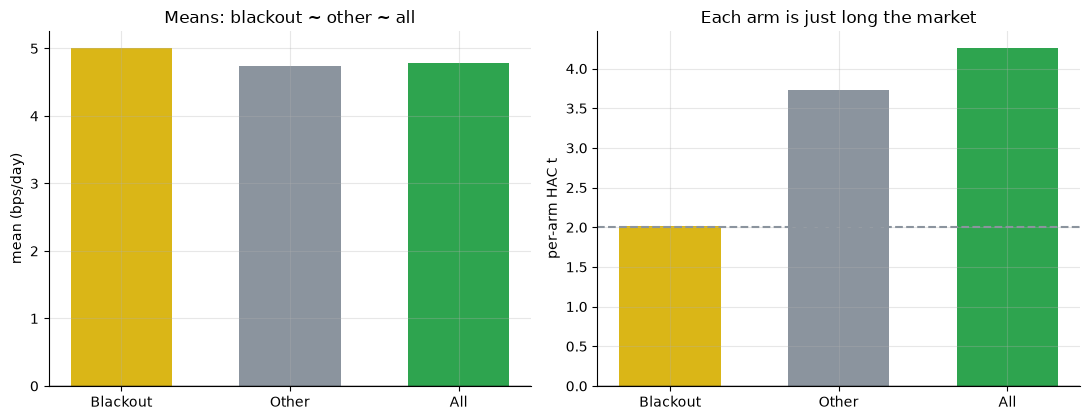

DIFF blackout-other = +0.27 bps   Welch t = +0.08  (statistical zero)


In [2]:
if HAVE_REAL:
    tbl = st.blackout_table(REAL)
    arms = ['blackout','other','all']
    means = [tbl[a]['mean_bps'] for a in arms]; ts = [tbl[a]['tstat'] for a in arms]
    diff, wt = tbl['diff_bps'], tbl['welch_t']
else:
    means = [5.0, 4.73, 4.79]
    ts = [2.02, 3.72, 4.26]; diff, wt = 0.27, 0.08
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
labels = ['Blackout','Other','All']
a1.bar(labels, means, color=[AMBER, GREY, GREEN], width=.6)
a1.set_ylabel('mean (bps/day)'); a1.set_title('Means: blackout ~ other ~ all')
a1.axhline(0, c='k', lw=1)
a2.bar(labels, ts, color=[AMBER, GREY, GREEN], width=.6)
a2.axhline(2, ls='--', c=GREY); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('per-arm HAC t'); a2.set_title('Each arm is just long the market')
plt.tight_layout(); plt.show()
print(f'DIFF blackout-other = {diff:+.2f} bps   Welch t = {wt:+.2f}  (statistical zero)')

> 💡 In plain words: all three arms sit around +4.8 bps/day — they are the *same* drift. The blackout arm's lone HAC *t* of +2.02 is just "the market went up," and the diff that would be an edge is +0.27 bps at *t* = +0.08. **H₁ rejected.**

### 4b · The calendar-shift placebo — no peak at the true window

Slide the 10-day window by a calendar offset and re-measure the diff. A real effect peaks at offset 0.

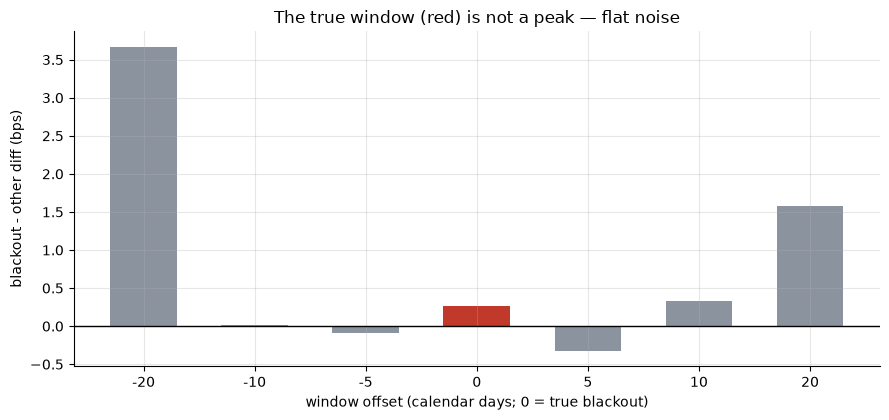

A real localised effect would tower at offset 0. It does not.


In [3]:
if HAVE_REAL:
    pl = st.placebo_shift(REAL, data.FOMC_DATES)
    offs = list(pl.index); diffs = list(pl['diff_bps'])
else:
    offs = [-20,-10,-5,0,5,10,20]
    diffs = [3.67, 0.01, -0.09, 0.27, -0.33, 0.34, 1.58]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [RED if o == 0 else GREY for o in offs]
ax.bar([str(o) for o in offs], diffs, color=cols, width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('window offset (calendar days; 0 = true blackout)')
ax.set_ylabel('blackout - other diff (bps)')
ax.set_title('The true window (red) is not a peak — flat noise')
plt.tight_layout(); plt.show()
print('A real localised effect would tower at offset 0. It does not.')

> 💡 In plain words: the true window's diff is *smaller* than several arbitrary shifts. Whatever wiggles there are, they aren't tied to the meeting. **H₃ rejected.**

### 4c · Calm? — and did anything decay?

Volatility inside vs outside the window, and the pre/post-2011 split.

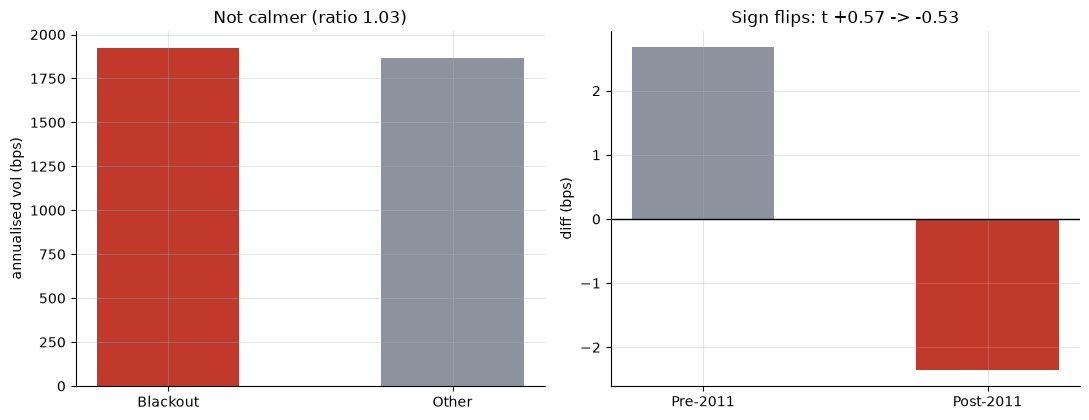

vol ratio 1.030 | pre diff +2.67 (t+0.57)  post -2.35 (t-0.53)


In [4]:
if HAVE_REAL:
    vt = st.vol_table(REAL); vb, vo = vt['blackout_vol_bps'], vt['other_vol_bps']
    era = st.split_by_era(REAL); pre, post = era['pre'], era['post']
    pre_d, pre_t = pre['diff_bps'], pre['welch_t']
    post_d, post_t = post['diff_bps'], post['welch_t']
else:
    vb, vo = 1922, 1866
    pre_d, pre_t, post_d, post_t = 2.67, 0.57, -2.35, -0.53
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['Blackout','Other'], [vb, vo], color=[RED, GREY], width=.5)
a1.set_ylabel('annualised vol (bps)'); a1.set_title(f'Not calmer (ratio {vb/vo:.2f})')
a2.bar(['Pre-2011','Post-2011'], [pre_d, post_d], color=[GREY, RED], width=.5)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('diff (bps)')
a2.set_title(f'Sign flips: t {pre_t:+.2f} -> {post_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'vol ratio {vb/vo:.3f} | pre diff {pre_d:+.2f} (t{pre_t:+.2f})  post {post_d:+.2f} (t{post_t:+.2f})')

> 💡 In plain words: the window is marginally *stormier* (ratio 1.03) — **H₂ rejected.** And the diff flips from +2.67 bps pre-2011 to -2.35 bps after, neither significant: there was never a stable effect to decay.

## 5 · The verdict

- **Signal `NONE`** — blackout − other = +0.27 bps/day, Welch *t* = +0.08; placebo flat; pre/post-2011 sign flip. The blackout level (+5.00 bps, HAC *t* +2.02) is pure equity beta.
- **Tradability `MIRAGE`** — blackout-only book +2.7%/yr vs +12.1%/yr B&H; excess Sharpe 0.30 < 0.64. Worse than buy-and-hold before a cent of cost.
- **Calm before the storm? `BUSTED`** — vol ratio 1.03 (higher).

## 6 · Could you trade it? — the excess-Sharpe race

Hold the index on blackout days, cash otherwise (~16 one-way trips/yr). Race it against buy-and-hold on an **excess-of-cash** basis, and sweep costs.

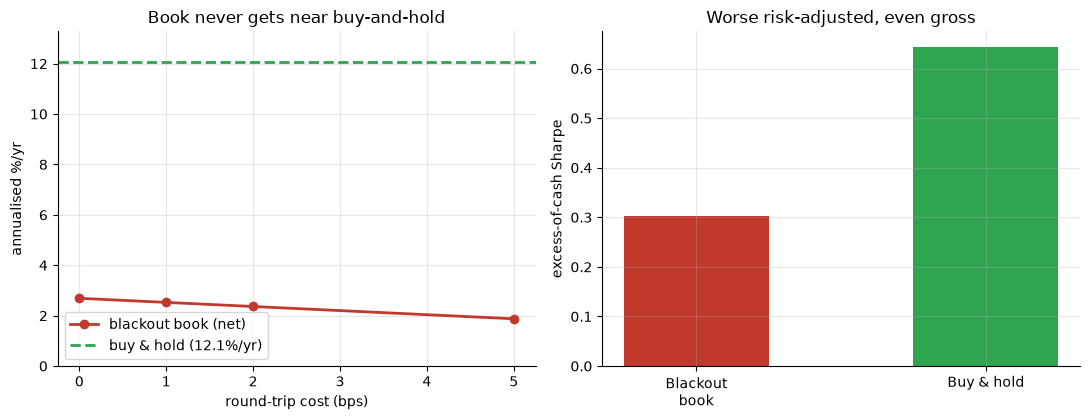

book excess Sharpe 0.303  vs  buy&hold 0.643


In [5]:
if HAVE_REAL:
    cs = st.cost_sweep(REAL); es = st.excess_sharpe(REAL)
    costs = list(cs.index); net = list(cs['book_net_ann_pct'])
    bh = cs['buyhold_ann_pct'].iloc[0]
    bsh, bhsh = es['book_excess_sharpe'], es['buyhold_excess_sharpe']
else:
    costs = [0.0,1.0,2.0,5.0]; net = [2.69, 2.53, 2.36, 1.87]
    bh = 12.07; bsh, bhsh = 0.3, 0.64
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(costs, net, 'o-', c=RED, lw=2, label='blackout book (net)')
a1.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.1f}%/yr)')
a1.set_xlabel('round-trip cost (bps)'); a1.set_ylabel('annualised %/yr')
a1.set_ylim(0, bh*1.1); a1.legend(); a1.set_title('Book never gets near buy-and-hold')
a2.bar(['Blackout\nbook','Buy & hold'], [bsh, bhsh], color=[RED, GREEN], width=.5)
a2.set_ylabel('excess-of-cash Sharpe'); a2.set_title('Worse risk-adjusted, even gross')
plt.tight_layout(); plt.show()
print(f'book excess Sharpe {bsh:.3f}  vs  buy&hold {bhsh:.3f}')

> 💡 In plain words: the book is dominated by buy-and-hold on *both* return and risk-adjusted return (excess Sharpe 0.30 vs 0.64), and that's *before* costs. There is no alpha to charge against — only a part-time slice of the beta you already owned. Textbook **Mirage**.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or does it always print zero? Plant a known blackout excess (and a known 'calm') and confirm it recovers them.

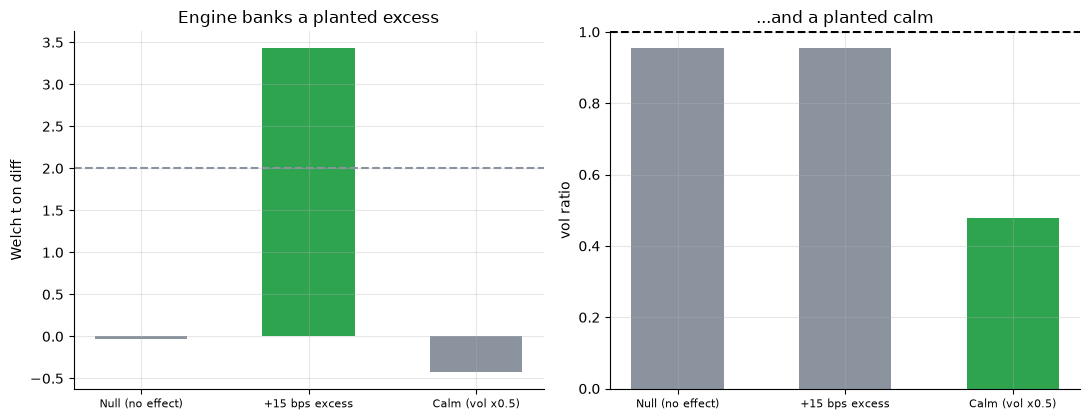

         planted  diff_bps  welch_t  vol_ratio
Null (no effect)    -0.156   -0.036      0.954
  +15 bps excess    14.844    3.437      0.954
 Calm (vol x0.5)    -1.190   -0.428      0.477


In [6]:
rows = []
for lab, exc, vm in [('Null (no effect)', 0.0, 1.0),
                     ('+15 bps excess', 0.0015, 1.0),
                     ('Calm (vol x0.5)', 0.0, 0.5)]:
    f, _ = data.synthetic_blackout(blackout_excess=exc, blackout_vol_mult=vm, seed=322)
    t = st.blackout_table(f); v = st.vol_table(f)
    rows.append((lab, t['diff_bps'], t['welch_t'], v['ratio']))
dfc = pd.DataFrame(rows, columns=['planted','diff_bps','welch_t','vol_ratio'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(dfc['planted'], dfc['welch_t'], color=[GREY, GREEN, GREY], width=.55)
a1.axhline(2, ls='--', c=GREY); a1.set_ylabel('Welch t on diff')
a1.set_title('Engine banks a planted excess'); a1.tick_params(axis='x', labelsize=8)
a2.bar(dfc['planted'], dfc['vol_ratio'], color=[GREY, GREY, GREEN], width=.55)
a2.axhline(1, ls='--', c='k'); a2.set_ylabel('vol ratio')
a2.set_title('...and a planted calm'); a2.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
print(dfc.round(3).to_string(index=False))

The harness recovers a planted +15 bps excess (Welch *t* ≈ +3.4) and a planted calm (vol ratio ≈ 0.48), and scores ~0 on the null. So its *silence* on the real tape is a statement about the **market**, not a broken pipeline: the FOMC blackout window carries no excess drift and no lull.

The one real effect nearby — the **24-hour** pre-FOMC drift (Lucca & Moench 2015) — lives inside this window but is a single day; spread over ten it averages out. For the *post*-meeting calendar, see [Study 135 — FOMC-Cycle](../../135-fomc-cycle/).